# Exploratory Data Analysis: Applicant Insights

## Objective

This notebook performs exploratory data analysis (EDA) on the cleaned applicant dataset from Week 1. We will follow a simple story-like flow for each question:

1. **Question** — what are we trying to answer?
2. **Numerical analysis** — calculate counts, percentages, and summaries.
3. **Visualization** — plot the results.
4. **Written takeaway** — explain what the numbers mean.

By the end, will be able to understand which domains are most popular, how applications changed over time, the overall status distribution, acceptance rates by domain, the top universities, and a bonus look at application days.


## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# Set a clean, consistent style for all charts
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 2. Load `applicants_cleaned.csv`

In [3]:
# Load the cleaned dataset. parse_dates ensures Application Date is loaded as a datetime column.
df = pd.read_csv(
    'applicants_cleaned.csv',
    parse_dates=['Application Date']
)

# Display the number of rows and columns
print('Dataset shape:', df.shape)

Dataset shape: (79, 7)


## 3. Dataset sanity check

In [4]:
# Basic information about the DataFrame
df.info()

# Show the first few rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Applicant Name    79 non-null     object        
 1   Email             79 non-null     object        
 2   Phone             79 non-null     int64         
 3   Domain Applied    79 non-null     object        
 4   University        79 non-null     object        
 5   Application Date  78 non-null     datetime64[ns]
 6   Status            79 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 4.4+ KB


,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status
0,Khadija Khan,khadija.khan1@example.com,325108603,Data Science,Lahore University of Management Sciences,2026-05-12,Rejected
1,Naveed Ali,naveed.ali2@example.com,348078673,Web Development,FAST NUCES,2025-03-28,Under Review
2,Ali Qureshi,ali.qureshi3@example.com,341445199,Graphic Design,COMSATS University Islamabad,2025-01-20,Selected
3,Mehwish Javed,mehwish.javed5@example.com,323608513,Data Science,NED University,2025-07-10,Under Review
4,Kamran Hussain,kamran.hussain6@example.com,326770619,Graphic Design,Ghulam Ishaq Khan Institute,2025-06-23,Rejected


In [5]:
# Check for missing values in each column
print('Missing values per column:')
print(df.isnull().sum())

# Confirm Application Date is datetime
print()
print('Application Date dtype:', df['Application Date'].dtype)

Missing values per column:
Applicant Name      0
Email               0
Phone               0
Domain Applied      0
University          0
Application Date    1
Status              0
dtype: int64

Application Date dtype: datetime64[ns]


### Takeaway: Dataset sanity check
- The dataset loaded successfully with **79 rows** and **7 columns**.
- `Application Date` is parsed as a **datetime64[ns]** column.
- The key columns (`Applicant Name`, `Email`, `Phone`, `Domain Applied`, `University`, `Application Date`, `Status`) are present, matching the expected Week 1 structure.
- Only `Application Date` has missing values (1 missing), which we will handle when performing time-based analyses.

## 4. Applications by domain

### Question

Which domain received the most applications?

In [7]:
# Count applications per domain
domain_counts = df['Domain Applied'].value_counts()
print(domain_counts)

Domain Applied
Digital Marketing    18
Data Science         17
Machine Learning     16
Graphic Design       14
Web Development      14
Name: count, dtype: int64


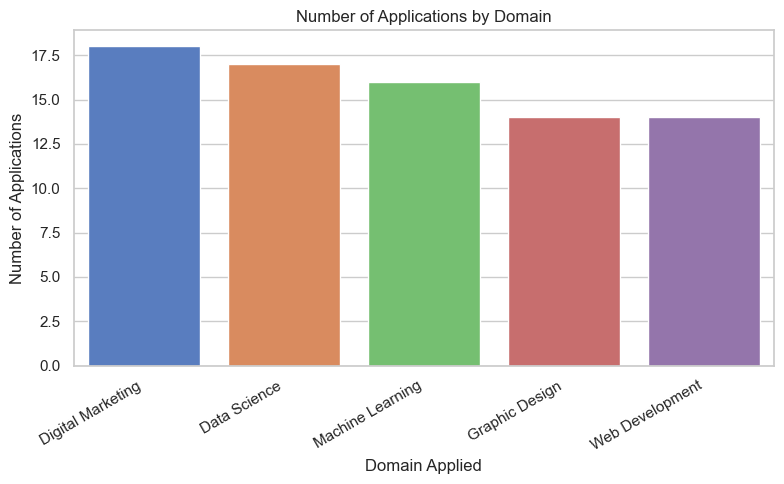

In [8]:
# Vertical bar chart for applications by domain
plt.figure(figsize=(8, 5))
sns.barplot(x=domain_counts.index, y=domain_counts.values, hue=domain_counts.index, legend=False)
plt.title('Number of Applications by Domain')
plt.xlabel('Domain Applied')
plt.ylabel('Number of Applications')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Takeaway: Applications by domain

- The most popular domain is **Digital Marketing** with **18** applications.
- The least popular domain is **Web Development** with **14** applications.
- The most popular domain received **4** more applications than the least popular domain, showing a clear preference among applicants.

## 5. Applications over time

### Question

How did applications change over time?

In [10]:
# Create a month-period column for aggregation
df['Application Month'] = df['Application Date'].dt.to_period('M')

# Count applications per month, sorted chronologically
monthly_trend = df.groupby('Application Month').size()
print(monthly_trend)

Application Month
2025-01     5
2025-02     4
2025-03    10
2025-04     2
2025-05     4
2025-06     8
2025-07     3
2025-08     6
2025-09     3
2025-10     8
2025-11     3
2025-12     3
2026-01     1
2026-02     3
2026-03     2
2026-04     6
2026-05     7
Freq: M, dtype: int64


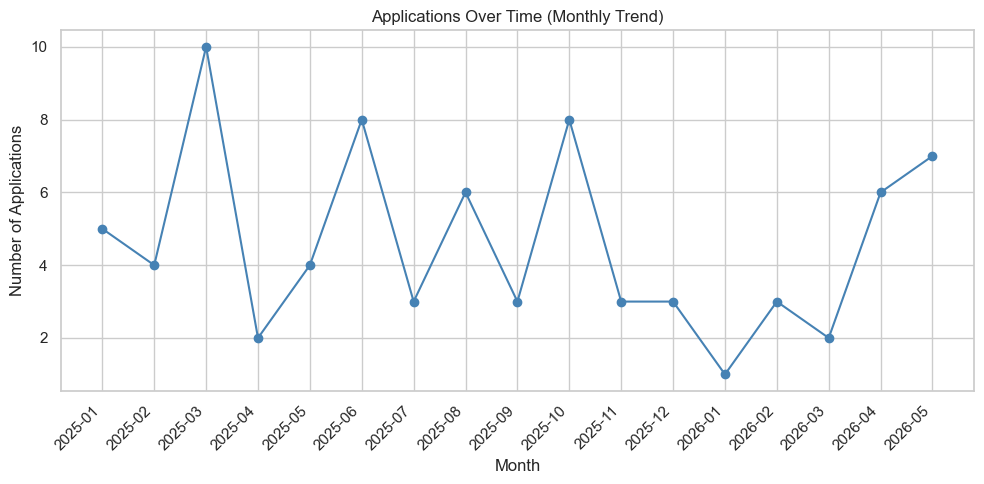

In [11]:
# Line chart with markers for monthly application counts
plt.figure(figsize=(10, 5))
plt.plot(monthly_trend.index.astype(str), monthly_trend.values, marker='o', linestyle='-', color='steelblue')
plt.title('Applications Over Time (Monthly Trend)')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Takeaway: Applications over time

- The month with the most applications was **2025-03** with **10** applications.
- The lowest monthly count was **1** applications.
- Overall, applications **increased** from the first month to the last, with some variation between months.

## 6. Overall application status

### Question

What is the overall distribution of applicant statuses?

In [13]:
# Raw status counts
status_counts = df['Status'].value_counts()
print('Status counts:')
print(status_counts)

# Status percentages
status_percentages = df['Status'].value_counts(normalize=True) * 100
print()
print('Status percentages:')
print(status_percentages.round(2))

Status counts:
Status
Under Review    29
Selected        27
Rejected        23
Name: count, dtype: int64

Status percentages:
Status
Under Review    36.71
Selected        34.18
Rejected        29.11
Name: proportion, dtype: float64


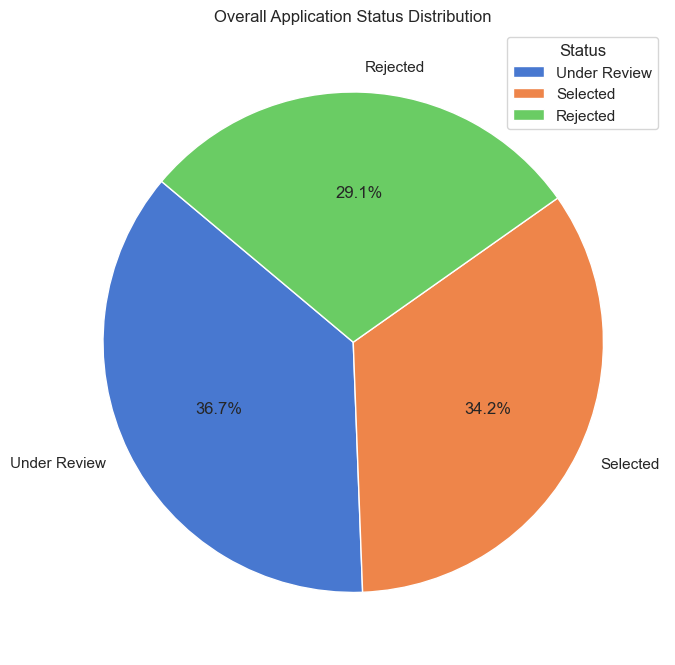

In [14]:
# Pie chart for overall status breakdown
plt.figure(figsize=(7, 7))
plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('muted', len(status_counts))
)
plt.title('Overall Application Status Distribution')
plt.ylabel('')  # Remove unnecessary y-axis label
plt.legend(title='Status', loc='best')
plt.tight_layout()
plt.show()

### Takeaway: Overall application status

- The largest status category is **Under Review** with **29** applicants (**36.71%**).
- **Selected**: **27** applicants (**34.18%**).
- **Rejected**: **23** applicants (**29.11%**).
- **Under Review**: **29** applicants (**36.71%**).

This distribution shows the overall outcome pattern for the applicant pool.

## 7. Application status and acceptance rate by domain

### Question

How do application statuses and acceptance rates differ across domains?

In [18]:
# Pivot table: status counts by domain
status_by_domain = pd.pivot_table(
    df,
    index='Domain Applied',
    columns='Status',
    values='Applicant Name',
    aggfunc='count',
    fill_value=0
)
print(status_by_domain)

Status             Rejected  Selected  Under Review
Domain Applied                                     
Data Science              6         5             6
Digital Marketing         6         4             8
Graphic Design            4         5             5
Machine Learning          4         8             4
Web Development           3         5             6


In [19]:
# Ensure required status columns exist (Selected, Rejected, Under Review)
for col in ['Selected', 'Rejected', 'Under Review']:
    if col not in status_by_domain.columns:
        status_by_domain[col] = 0

# Calculate total applications per domain and acceptance rate
status_by_domain = status_by_domain.reset_index()
status_by_domain['Total Applications'] = status_by_domain['Selected'] + status_by_domain['Rejected'] + status_by_domain['Under Review']
status_by_domain['Acceptance Rate (%)'] = (status_by_domain['Selected'] / status_by_domain['Total Applications'] * 100).round(2)

# Display a clean summary table
summary_table = status_by_domain[['Domain Applied', 'Total Applications', 'Selected', 'Rejected', 'Under Review', 'Acceptance Rate (%)']]
print(summary_table)

Status     Domain Applied  Total Applications  Selected  Rejected  \
0            Data Science                  17         5         6   
1       Digital Marketing                  18         4         6   
2          Graphic Design                  14         5         4   
3        Machine Learning                  16         8         4   
4         Web Development                  14         5         3   

Status  Under Review  Acceptance Rate (%)  
0                  6                29.41  
1                  8                22.22  
2                  5                35.71  
3                  4                50.00  
4                  6                35.71  


<Figure size 1000x600 with 0 Axes>

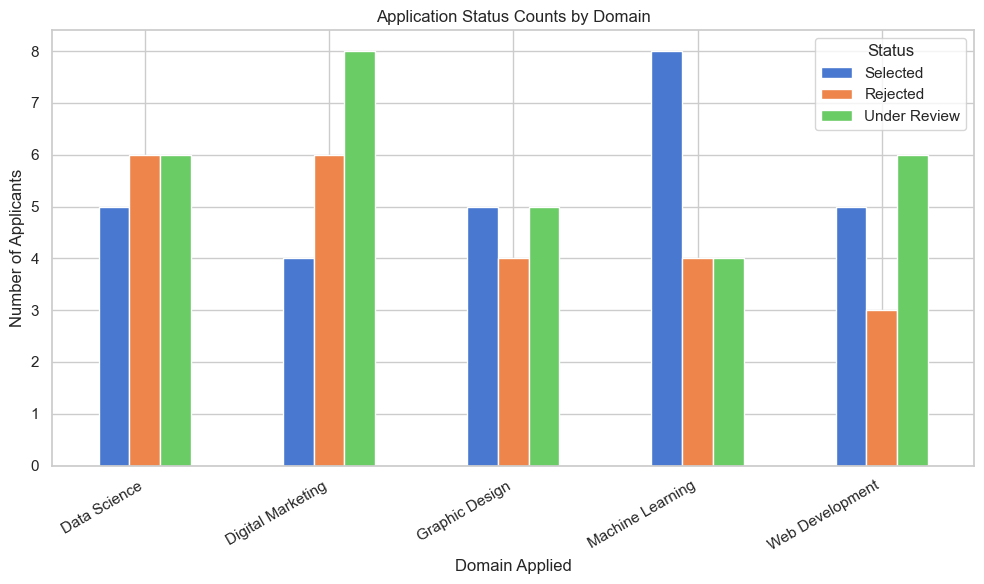

In [20]:
# Grouped bar chart of status counts by domain
plt.figure(figsize=(10, 6))
summary_table_plot = summary_table.set_index('Domain Applied')[['Selected', 'Rejected', 'Under Review']]
summary_table_plot.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Application Status Counts by Domain')
plt.xlabel('Domain Applied')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

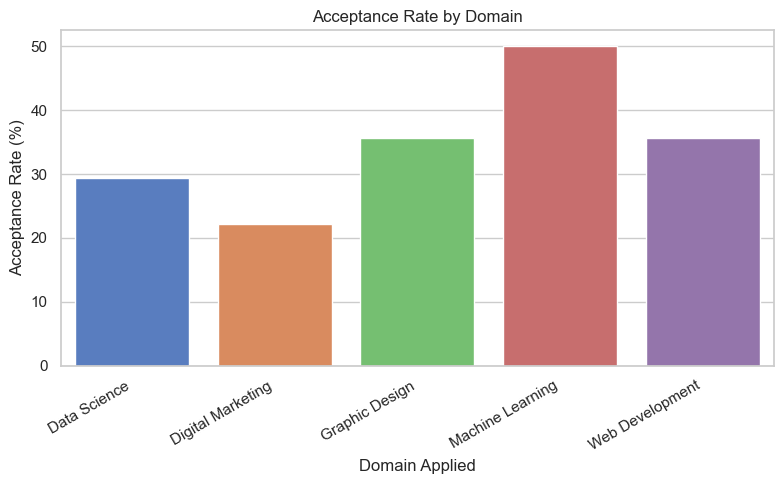

In [21]:
# Bar chart of acceptance rate by domain
plt.figure(figsize=(8, 5))
sns.barplot(x='Domain Applied', y='Acceptance Rate (%)', data=summary_table, hue='Domain Applied', legend=False)
plt.title('Acceptance Rate by Domain')
plt.xlabel('Domain Applied')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Takeaway: Status and acceptance rate by domain

- The domain with the **highest** acceptance rate is **Machine Learning** at **50.0%**.
- The domain with the **lowest** acceptance rate is **Digital Marketing** at **22.22%**.
- The most popular domain by application volume was **Digital Marketing**, which **did not** have the highest acceptance rate. This shows that popularity does not necessarily translate to higher selection rates.

## 8. Top universities

### Question

Which universities sent the most applicants?

In [23]:
# Top 10 universities by number of applicants
top_universities = df['University'].value_counts().head(10)
print(top_universities)

University
National University of Computer and Emerging Sciences    13
COMSATS University Islamabad                             10
NED University                                            9
Lahore University of Management Sciences                  8
University of Engineering and Technology Lahore           7
University of the Punjab                                  6
National University of Sciences & Technology              6
Ghulam Ishaq Khan Institute                               6
University of Karachi                                     5
Institute of Space Technology                             4
Name: count, dtype: int64


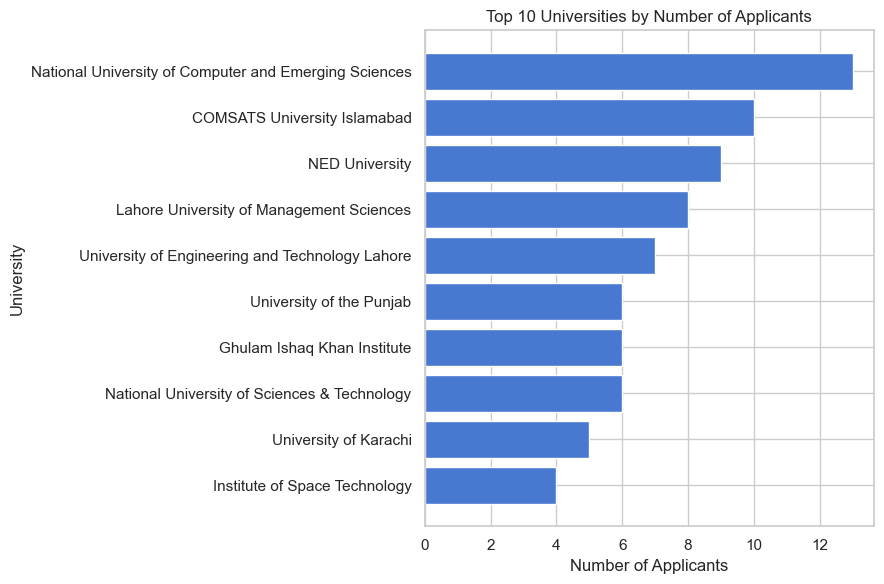

In [28]:
# Horizontal bar chart of top 10 universities, largest at the top
plt.figure(figsize=(9, 6))
top_universities_sorted = top_universities.sort_values()
plt.barh(top_universities_sorted.index, top_universities_sorted.values)
plt.title('Top 10 Universities by Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('University')
plt.tight_layout()
plt.show()

### Takeaway: Top universities

- The university with the most applicants is **National University of Computer and Emerging Sciences** with **13** applicants.
- The combined contribution of the top three universities is **32** applicants.
- These top three universities represent **40.51%** of all applicants, showing that a small number of institutions contribute a large share of the applications.

## 9. Bonus analysis: Applications by day of week

### Why this question?

Understanding which days of the week applications arrive most frequently can help the program team plan review schedules, support hours, and outreach timing.

In [26]:
# Extract day of week from Application Date
df['Application Day'] = df['Application Date'].dt.day_name()

# Count applications per day, ordered from Monday to Sunday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['Application Day'].value_counts().reindex(day_order)
print(day_counts)

Application Day
Monday       20
Tuesday       9
Wednesday     9
Thursday      9
Friday       14
Saturday     13
Sunday        4
Name: count, dtype: int64


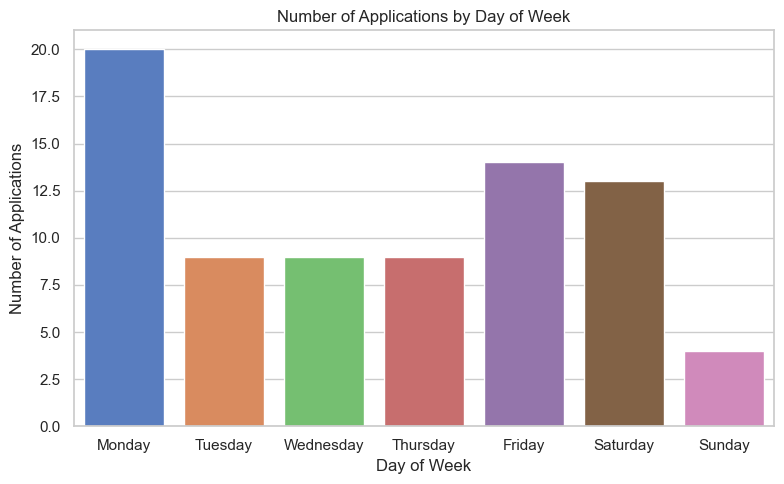

In [30]:
# Bar chart of applications by day of week
plt.figure(figsize=(8, 5))
sns.barplot(x=day_counts.index, y=day_counts.values, hue=day_counts.index, legend=False)
plt.title('Number of Applications by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()

### Takeaway: Applications by day of week

- The busiest application day is **Monday** with **20** applications.
- The least active day is **Sunday** with **4** applications.
- Weekday applications (Monday-Friday) totaled **61**, while weekend applications (Saturday-Sunday) totaled **17**, indicating that **weekdays** saw more submissions.

## 10. Key insights

- **Domain popularity:** **Digital Marketing** is the most popular domain, receiving **18** out of **79** total applications. This suggests the program should allocate more review capacity and resources to this domain.

- **Application trends over time:** The peak application month was **2025-03** with **10** applications. The monthly trend shows **increased** over the observed period, which can inform future recruitment timing.

- **Acceptance rates:** **Machine Learning** has the highest acceptance rate at **50.0%**, while **Digital Marketing** has the lowest at **22.22%**. This shows that the most applied-to domain is not always the one with the highest selection rate.

- **University contribution:** **National University of Computer and Emerging Sciences** is the top contributor with **13** applicants. The top three universities together account for **40.51%** of all applications, highlighting key partner institutions.

- **Bonus insight - weekly pattern:** **Monday** is the busiest day for applications (**20**), while **Sunday** is the quietest (**4**). This helps the team decide when to schedule application processing.

## 11. Final conclusion

This EDA explored the applicant dataset through counts, percentages, and visualizations. We found that **Digital Marketing** attracted the most interest, **2025-03** saw the highest monthly volume, and the overall status distribution is led by **Under Review**. Domain-level acceptance rates reveal that popularity and selection success do not always align. The top universities and weekly application patterns provide practical guidance for program operations. All findings were calculated directly from the cleaned dataset, ensuring accuracy and reproducibility.